In [7]:
%pip uninstall -y pandas numpy

Found existing installation: pandas 2.3.2
Uninstalling pandas-2.3.2:
  Successfully uninstalled pandas-2.3.2
Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install --no-cache-dir numpy pandas

     ---------------------------------------- 12.9/12.9 MB 3.4 MB/s eta 0:00:00
     ---------------------------------------- 11.3/11.3 MB 3.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install numpy pandas scipy scikit-learn matplotlib seaborn openpyxl

     -------------------------------------- 250.9/250.9 kB 3.1 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.21.4
    Uninstalling numpy-1.21.4:
      Successfully uninstalled numpy-1.21.4
Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Asus\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~umpy\\.libs\\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

RAW = r"D:/global_ai_race_analytics/data/raw"  # change to your folder path

idx = pd.read_csv(f"{RAW}/AI_index_db.csv")
inv = pd.read_csv(f"{RAW}/4_Investment_By_Country.csv", skiprows=2)   # first 2 rows are title text
sent = pd.read_csv(f"{RAW}/6_Public_Sentiment_By_Country.csv", skiprows=2)

print(idx.shape, inv.shape, sent.shape)

(62, 13) (14, 8) (13, 5)


In [3]:
NAME_FIX = {
    "United States of America": "United States",
    "The Netherlands": "Netherlands",
}

def clean_country_col(series):
    return series.astype(str).str.strip().replace(NAME_FIX)

idx["Country"] = clean_country_col(idx["Country"])
inv = inv.rename(columns={"Country / Region": "Country"})
inv["Country"] = clean_country_col(inv["Country"])
sent["Country"] = clean_country_col(sent["Country"])

In [4]:
JUNK_VALUES = {"Global Total (Corp)", "of which: GenAI", "Global Average"}

def drop_junk_rows(df, col):
    mask = df[col].isin(JUNK_VALUES) | df[col].str.contains(
        "SOURCE|VERIFIED|Stanford|GREEN rows", case=False, na=False, regex=True
    )
    return df[~mask].copy()

inv = drop_junk_rows(inv, "Country")
sent = drop_junk_rows(sent, "Country")

In [5]:
idx = idx.rename(columns={"Total score": "AI_Index_Total_Score"})

money_cols = [c for c in inv.columns if "$B" in c]
for c in money_cols:
    inv[c] = pd.to_numeric(inv[c], errors="coerce")
inv = inv.rename(columns={c: f"Investment_{c.replace(' ($B)', '')}_USD_B" for c in money_cols})
inv = inv.drop(columns=["Notes"], errors="ignore")

pct_cols = [c for c in sent.columns if c.startswith("%")]
for c in pct_cols:
    sent[c] = pd.to_numeric(sent[c], errors="coerce")  # turns "N/A" into NaN
sent = sent.rename(columns={
    "% See AI as Beneficial (2024)": "Sentiment_Beneficial_Pct",
    "% Believe AI Will Change Their Job (5yr)": "Sentiment_JobChange_Pct",
    "% Fear AI Will Replace Job (5yr)": "Sentiment_FearReplace_Pct",
})
sent = sent.drop(columns=["Notes"], errors="ignore")

In [6]:
master = idx.merge(inv, on="Country", how="left")
master = master.merge(sent, on="Country", how="left")
master = master.sort_values("AI_Index_Total_Score", ascending=False).reset_index(drop=True)

master.to_csv("master_ai_country_data.csv", index=False)
print(master.shape)
master.head()


(62, 22)


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,AI_Index_Total_Score,Region,...,Political regime,Investment_2019_USD_B,Investment_2020_USD_B,Investment_2021_USD_B,Investment_2022_USD_B,Investment_2023_USD_B,Investment_2024_USD_B,Sentiment_Beneficial_Pct,Sentiment_JobChange_Pct,Sentiment_FearReplace_Pct
0,United States,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,...,Liberal democracy,22.0,26.6,52.9,47.4,67.2,109.1,0.39,NaN,NaN
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,...,Closed autocracy,8.8,9.1,17.2,13.4,8.0,9.3,0.83,0.44,NaN
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,...,Liberal democracy,1.8,2.1,4.1,4.5,3.8,4.5,0.42,NaN,NaN
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,...,Liberal democracy,1.2,1.4,2.5,2.8,2.6,3.1,0.40,NaN,NaN
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,...,Liberal democracy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
numeric_df = master.select_dtypes(include="number")

print(master.isna().sum())          # missing values per column
print(numeric_df.describe().round(2))  # mean, std, min, max, etc.
print(master[["Country", "AI_Index_Total_Score"]].head(10))  # top countries

Country                       0
Talent                        0
Infrastructure                0
Operating Environment         0
Research                      0
Development                   0
Government Strategy           0
Commercial                    0
AI_Index_Total_Score          0
Region                        0
Cluster                       0
Income group                  0
Political regime              0
Investment_2019_USD_B        52
Investment_2020_USD_B        52
Investment_2021_USD_B        52
Investment_2022_USD_B        52
Investment_2023_USD_B        52
Investment_2024_USD_B        52
Sentiment_Beneficial_Pct     52
Sentiment_JobChange_Pct      61
Sentiment_FearReplace_Pct    62
dtype: int64
       Talent  Infrastructure  Operating Environment  Research  Development  \
count   62.00           62.00                  62.00     62.00        62.00   
mean    16.80           63.50                  66.93     16.61        14.82   
std     15.21           20.22                 

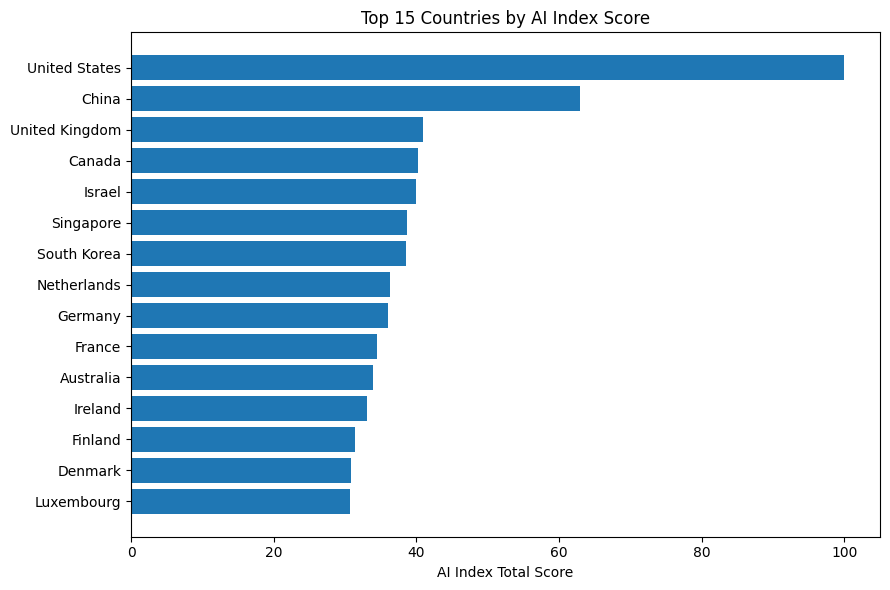

In [8]:
import matplotlib.pyplot as plt

top15 = master.nlargest(15, "AI_Index_Total_Score")
plt.figure(figsize=(9, 6))
plt.barh(top15["Country"][::-1], top15["AI_Index_Total_Score"][::-1])
plt.xlabel("AI Index Total Score")
plt.title("Top 15 Countries by AI Index Score")
plt.tight_layout()
plt.show()

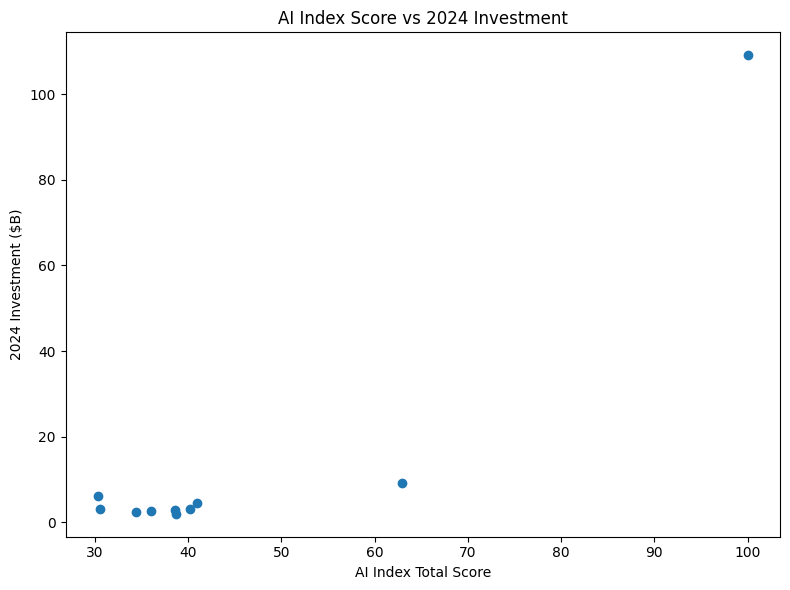

In [9]:
plt.figure(figsize=(8, 6))
sub = master.dropna(subset=["Investment_2024_USD_B"])
plt.scatter(sub["AI_Index_Total_Score"], sub["Investment_2024_USD_B"])
plt.xlabel("AI Index Total Score")
plt.ylabel("2024 Investment ($B)")
plt.title("AI Index Score vs 2024 Investment")
plt.tight_layout()
plt.show()